In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load locked Task 8 seed-42 predictions
pred_df = pd.read_csv(
    "TASK8_seed_42_predictions.csv"
)

print("========== TASK 9 DATA CHECK ==========\n")

print("Rows:", len(pred_df))
print("Columns:", pred_df.columns.tolist())

print("\nFirst 5 rows:")
display(pred_df.head())

# Verify required columns
assert "actual_rul" in pred_df.columns
assert "predicted_rul" in pred_df.columns

# Check for missing values
print("\nMissing values:")
print(pred_df[["actual_rul", "predicted_rul"]].isna().sum())

assert pred_df[["actual_rul", "predicted_rul"]].isna().sum().sum() == 0

print("\n✅ Task 9 prediction data loaded and verified")

========== TASK 9 DATA CHECK ==========

Rows: 9450
Columns: ['actual_rul', 'predicted_rul']

First 5 rows:


,actual_rul,predicted_rul
0,284.0,169.98306
1,283.2,169.92825
2,282.4,169.78897
3,280.8,169.56104
4,279.8,169.20380



Missing values:
actual_rul       0
predicted_rul    0
dtype: int64

✅ Task 9 prediction data loaded and verified


In [2]:
# Define RUL ranges
bins = [
    (0, 50, "0-50"),
    (50, 100, "50-100"),
    (100, 200, "100-200"),
    (200, 300, "200-300"),
    (300, np.inf, ">300")
]

range_results = []

for lower, upper, label in bins:

    mask = (
        (pred_df["actual_rul"] >= lower) &
        (pred_df["actual_rul"] < upper)
    )

    y_true = pred_df.loc[mask, "actual_rul"]
    y_pred = pred_df.loc[mask, "predicted_rul"]

    count = len(y_true)

    if count > 0:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(
            mean_squared_error(y_true, y_pred)
        )
    else:
        mae = np.nan
        rmse = np.nan

    range_results.append({
        "RUL_Range": label,
        "Count": count,
        "MAE": mae,
        "RMSE": rmse
    })

range_results_df = pd.DataFrame(range_results)

print("========== TASK 9 — RUL RANGE ERROR ANALYSIS ==========\n")
display(range_results_df)

========== TASK 9 — RUL RANGE ERROR ANALYSIS ==========



,RUL_Range,Count,MAE,RMSE
0,0-50,3536,37.544549,52.892937
1,50-100,2539,33.320068,41.276931
2,100-200,2707,46.801262,58.468257
3,200-300,634,106.743868,115.207133
4,>300,34,159.805106,160.869821


In [3]:
range_results_df.to_csv(
    "TASK9_rul_range_error_analysis.csv",
    index=False
)

task9_config = pd.DataFrame({
    "Parameter": [
        "model",
        "seed",
        "sequence_length",
        "input_features",
        "rul_bins"
    ],
    "Value": [
        "LSTM",
        42,
        20,
        105,
        "0-50, 50-100, 100-200, 200-300, >300"
    ]
})

task9_config.to_csv(
    "TASK9_rul_range_config.csv",
    index=False
)

print("Saved: TASK9_rul_range_error_analysis.csv")
print("Saved: TASK9_rul_range_config.csv")

display(range_results_df)

Saved: TASK9_rul_range_error_analysis.csv
Saved: TASK9_rul_range_config.csv


,RUL_Range,Count,MAE,RMSE
0,0-50,3536,37.544549,52.892937
1,50-100,2539,33.320068,41.276931
2,100-200,2707,46.801262,58.468257
3,200-300,634,106.743868,115.207133
4,>300,34,159.805106,160.869821


In [4]:
import os
import pandas as pd

print("========== TASK 9 FINAL CHECK ==========\n")

results = pd.read_csv(
    "TASK9_rul_range_error_analysis.csv"
)

config = pd.read_csv(
    "TASK9_rul_range_config.csv"
)

print("RUL range results:")
display(results)

# Expected ranges
expected_ranges = [
    "0-50",
    "50-100",
    "100-200",
    "200-300",
    ">300"
]

assert results["RUL_Range"].tolist() == expected_ranges
assert len(results) == 5

# No missing metrics
assert results[["Count", "MAE", "RMSE"]].isna().sum().sum() == 0

print("Range analysis check: PASS")
print("Configuration check: PASS")

# Required files
required_files = [
    "TASK9_rul_range_error_analysis.csv",
    "TASK9_rul_range_config.csv"
]

for f in required_files:
    assert os.path.exists(f)
    print(f"{f}: PASS")

print("\n✅ TASK 9 LOCKED SUCCESSFULLY")

========== TASK 9 FINAL CHECK ==========

RUL range results:


,RUL_Range,Count,MAE,RMSE
0,0-50,3536,37.544549,52.892937
1,50-100,2539,33.320068,41.276931
2,100-200,2707,46.801262,58.468257
3,200-300,634,106.743868,115.207133
4,>300,34,159.805106,160.869821


Range analysis check: PASS
Configuration check: PASS
TASK9_rul_range_error_analysis.csv: PASS
TASK9_rul_range_config.csv: PASS

✅ TASK 9 LOCKED SUCCESSFULLY


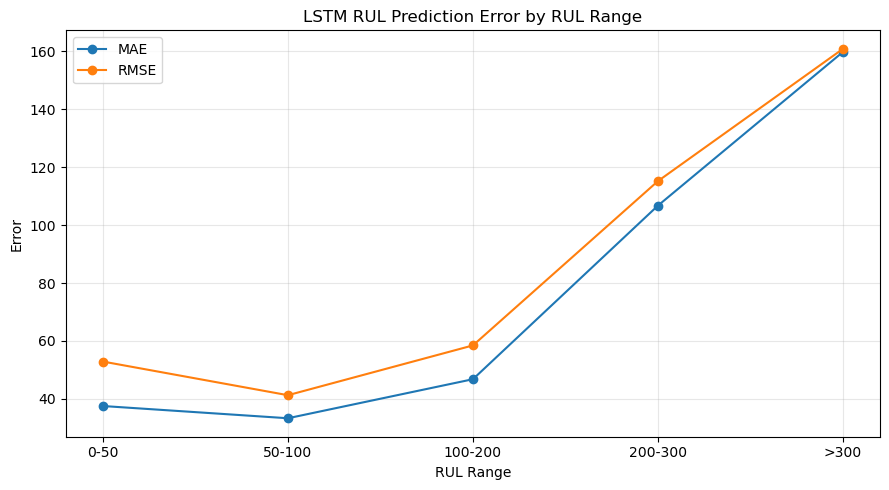

Saved: TASK9_rul_range_error_analysis.png


In [5]:
# ============================================================
# TASK 9 — SAVE RUL RANGE ERROR ANALYSIS FIGURE
# ============================================================

import matplotlib.pyplot as plt

rul_plot_df = pd.DataFrame({
    "RUL Range": ["0-50", "50-100", "100-200", "200-300", ">300"],
    "MAE": [37.544549, 33.320068, 46.801262, 106.743868, 159.805106],
    "RMSE": [52.892937, 41.276931, 58.468257, 115.207133, 160.869821]
})

plt.figure(figsize=(9, 5))

x = range(len(rul_plot_df))

plt.plot(x, rul_plot_df["MAE"],
         marker="o", label="MAE")
plt.plot(x, rul_plot_df["RMSE"],
         marker="o", label="RMSE")

plt.xlabel("RUL Range")
plt.ylabel("Error")
plt.title("LSTM RUL Prediction Error by RUL Range")
plt.xticks(list(x), rul_plot_df["RUL Range"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "TASK9_rul_range_error_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: TASK9_rul_range_error_analysis.png")